In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import entropy
from copy import deepcopy
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import seaborn as sns
from collections import Counter
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import cross_val_predict, cross_validate
from sklearn.utils.class_weight import compute_class_weight

# Работа с базовой моделью (Случайный лес) на данных после уменьшения выборки "нормы" с помощью кластеризации KMeans

In [ ]:
df_clustered = pd.read_parquet("anem_with_features_clustered_kmeans.parquet")

In [ ]:
df_clustered

,sex,RBC,HGB,HCT,MCV,MCH,MCHC,RDW-CV,label,microcytoz,...,new_age_5,new_age_6,new_age_7,new_age_8,new_age_9,new_age_10,new_age_11,new_age_12,new_age_13,new_age_14
0,1,4.55,97.0,31.9,70.2,21.2,304.0,22.0,2,True,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,3.57,96.0,30.2,84.5,26.9,318.0,15.0,2,False,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,4.92,115.0,37.1,75.5,23.4,310.0,15.0,2,True,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,4.53,99.0,32.4,71.6,21.9,306.0,16.8,2,True,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,4.11,117.0,36.0,87.5,28.6,325.0,14.2,2,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10023,0,4.25,127.2,39.1,92.0,29.9,325.0,14.4,0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10024,0,4.20,127.0,39.0,92.8,30.2,326.0,13.9,0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10025,0,4.98,138.0,41.9,84.1,27.8,329.0,16.2,0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10026,0,4.12,126.0,37.9,92.1,30.7,332.0,12.9,0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
df_clustered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10028 entries, 0 to 10027
Data columns (total 28 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sex         10028 non-null  int64  
 1   RBC         10028 non-null  float64
 2   HGB         10028 non-null  float64
 3   HCT         10028 non-null  float64
 4   MCV         10028 non-null  float64
 5   MCH         10028 non-null  float64
 6   MCHC        10028 non-null  float64
 7   RDW-CV      10028 non-null  float64
 8   label       10028 non-null  int64  
 9   microcytoz  10028 non-null  bool   
 10  macrocytoz  10028 non-null  bool   
 11  hypohrom    10028 non-null  bool   
 12  hyperhrom   10028 non-null  bool   
 13  new_age_0   10028 non-null  float64
 14  new_age_1   10028 non-null  float64
 15  new_age_2   10028 non-null  float64
 16  new_age_3   10028 non-null  float64
 17  new_age_4   10028 non-null  float64
 18  new_age_5   10028 non-null  float64
 19  new_age_6   10028 non-nul

In [ ]:
df = df_clustered

## Проверка модели

In [ ]:
def evaluate_model(model, X_train, y_train, X_test, y_test, class_names=None, cv=None):
    """
    Обучает модель с возможной кросс-валидацией, выводит classification_report и confusion matrix.

    Параметры:
    model : объект классификатора
    X_train, y_train : обучающие данные
    X_test, y_test : тестовые данные
    class_names : список названий классов (опционально)
    cv : int или None - число фолдов для кросс-валидации. Если None, кросс-валидация не выполняется.

    Возвращает:
    model : обученная на всех train данных модель
    """

    # Если задана кросс-валидация, выполняем её на обучающей выборке
    if cv is not None:
        print(f"=== Кросс-валидация ({cv} фолдов) на обучающей выборке ===")
        # Используем cross_validate для получения нескольких метрик
        scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
        cv_results = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, return_train_score=False)

        print(f"Accuracy: {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std():.4f})")
        print(f"Precision (macro): {cv_results['test_precision_macro'].mean():.4f} (+/- {cv_results['test_precision_macro'].std():.4f})")
        print(f"Recall (macro): {cv_results['test_recall_macro'].mean():.4f} (+/- {cv_results['test_recall_macro'].std():.4f})")
        print(f"F1 (macro): {cv_results['test_f1_macro'].mean():.4f} (+/- {cv_results['test_f1_macro'].std():.4f})")


        # Дополнительно: матрица ошибок по кросс-валидации (предсказания для всех фолдов)
        y_train_pred_cv = cross_val_predict(model, X_train, y_train, cv=cv)

        print("\nClassification Report (Cross-validation):")
        print(classification_report(y_train, y_train_pred_cv, target_names=class_names))

        cm_cv = confusion_matrix(y_train, y_train_pred_cv)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm_cv, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names)
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.title(f'Confusion Matrix (Cross-validation, {cv} folds)')
        plt.show()
        print("\n" + "="*50 + "\n")

    # Финальное обучение на всех тренировочных данных
    print("Обучение финальной модели на всех тренировочных данных...")
    model.fit(X_train, y_train)

    # Предсказание на тестовой выборке
    y_pred = model.predict(X_test)

    # Отчёт по классификации на тесте
    print("Classification Report на тестовой выборке:")
    if class_names is None:
        class_names = [f"Class {i}" for i in np.unique(y_test)]
    print(classification_report(y_test, y_pred, target_names=class_names))

    # Матрица ошибок на тесте
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix (Test set)')
    plt.show()

    return model

Готово! Колонки отмасштабированы:
['HCT', 'HGB', 'MCHC', 'MCH', 'MCV', 'RBC', 'RDW-CV']

Средние после масштабирования:
HCT       0.0
HGB       0.0
MCHC      0.0
MCH      -0.0
MCV      -0.0
RBC       0.0
RDW-CV    0.0
dtype: float64

Стандартные отклонения после масштабирования:
HCT       1.00005
HGB       1.00005
MCHC      1.00005
MCH       1.00005
MCV       1.00005
RBC       1.00005
RDW-CV    1.00005
dtype: float64
=== Кросс-валидация (2 фолдов) на обучающей выборке ===
Accuracy: 0.9643 (+/- 0.0045)
Precision (macro): 0.6634 (+/- 0.0389)
Recall (macro): 0.6581 (+/- 0.0027)
F1 (macro): 0.6521 (+/- 0.0141)

Classification Report (Cross-validation):
                          precision    recall  f1-score   support

                   Норма       1.00      1.00      1.00      6606
              Анемия B12       0.41      0.27      0.32        49
 Железодефицитная анемия       0.90      0.89      0.89      1122
Фолиеводефицитная анемия       0.31      0.28      0.30       158
         Бет

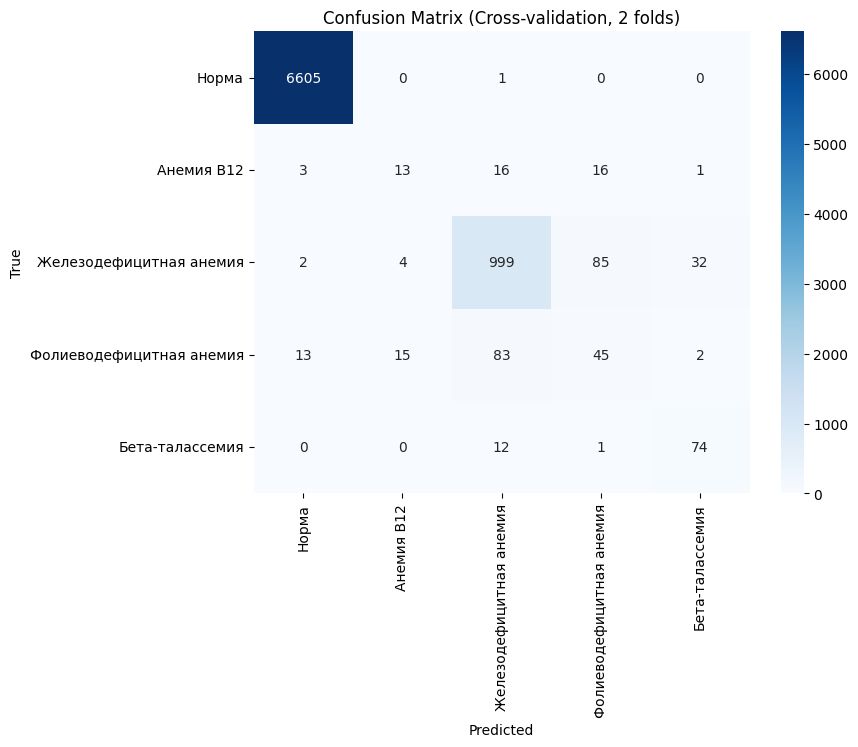



Обучение финальной модели на всех тренировочных данных...
Classification Report на тестовой выборке:
                          precision    recall  f1-score   support

                   Норма       1.00      1.00      1.00      1652
              Анемия B12       0.44      0.33      0.38        12
 Железодефицитная анемия       0.93      0.94      0.93       280
Фолиеводефицитная анемия       0.52      0.42      0.47        40
         Бета-талассемия       0.81      0.95      0.88        22

                accuracy                           0.98      2006
               macro avg       0.74      0.73      0.73      2006
            weighted avg       0.97      0.98      0.97      2006



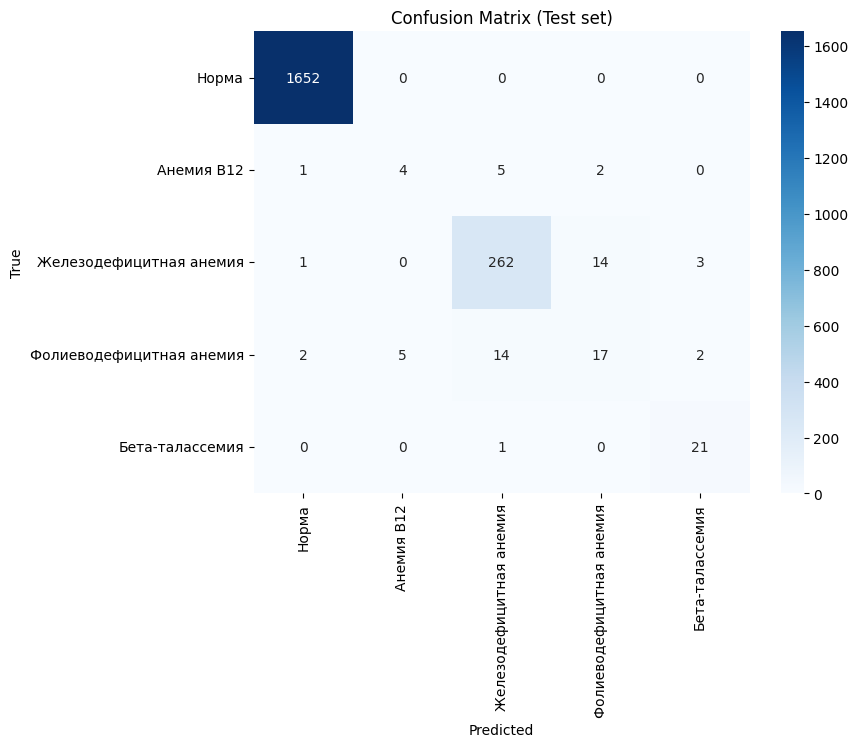

In [ ]:
features = [c for c in df.columns if c != 'label']

class_names = [
    "Норма",
    "Анемия B12",
    "Железодефицитная анемия",
    "Фолиеводефицитная анемия",
    "Бета-талассемия"
]

# Список колонок для масштабирования
cols_to_scale = ['HCT', 'HGB', 'MCHC', 'MCH', 'MCV', 'RBC', 'RDW-CV']

# Создаем копию DataFrame
df_scaled = df.copy()

# Инициализируем scaler
scaler = StandardScaler()

# Масштабируем только выбранные колонки
df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print("Готово! Колонки отмасштабированы:")
print(cols_to_scale)

# Проверка: средние должны быть ~0, std ~1
print("\nСредние после масштабирования:")
print(df_scaled[cols_to_scale].mean().round(6))
print("\nСтандартные отклонения после масштабирования:")
print(df_scaled[cols_to_scale].std().round(6))

X_train, X_test, y_train, y_test = train_test_split(
    df_scaled[features], df_scaled['label'],
    test_size=0.2,
    random_state=62,
    stratify=df_scaled['label']
)

class_weight = compute_class_weight('balanced', classes=np.unique(y_test), y=y_test)
class_weights = {i: class_weight[i] for i in range(5)}
class_weights

# Обучаем модель на всей обучающей части (X_train_full, y_train_full)
model_rf = RandomForestClassifier(n_estimators=295,
                             max_depth=16,
                             min_samples_leaf=4,
                             random_state=42,
                             class_weight=class_weights)

model = evaluate_model(model_rf, X_train, y_train, X_test, y_test, class_names, cv=2)

In [ ]:
df['label'].value_counts()

,count
label,
0,8258
2,1402
3,198
4,109
1,61


# Подготовка данных для базовой модели и стратегий активного обучения

In [ ]:
df = pd.read_parquet("anem_with_features_20_04.parquet")

In [ ]:
df

,,sex,WBC,RBC,HGB,HCT,MCV,MCH,MCHC,PLT,RDW-CV,...,new_age_5,new_age_6,new_age_7,new_age_8,new_age_9,new_age_10,new_age_11,new_age_12,new_age_13,new_age_14
hash,date,,,,,,,,,,,,,,,,,,,,,
10000DD5EE2152,2025-08-18 08:01:09.777000000,0,4.72,4.50,131.0,39.9,88.6,29.1,328.0,283.0,14.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10015157EB63D2,2025-09-08 11:46:42.487000000,0,5.11,4.27,128.0,37.1,86.8,30.0,345.0,292.0,12.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1004CEA5699C2A,2025-08-13 09:20:43.547000000,0,5.68,4.72,138.0,41.7,88.4,29.2,331.0,191.0,12.7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10098CE9E11631,2025-08-31 11:50:16.597000000,1,4.11,5.30,160.0,47.2,89.1,30.3,339.0,247.0,12.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100B15E74BB952,2025-10-07 08:15:57.740000000,0,4.54,4.69,140.0,40.8,86.9,29.9,343.0,258.0,12.7,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224,2024-07-25 12:15:47.177000,1,NaN,6.21,38.4,128.0,61.8,20.7,333.0,NaN,17.4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
236,2024-07-12 11:12:29.717000,0,NaN,5.41,31.9,103.0,58.9,19.0,323.0,NaN,21.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
237,2024-10-03 11:57:01.617000,0,NaN,5.31,27.2,76.0,51.2,14.4,279.0,NaN,21.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df = df.drop(columns=['WBC', 'PLT'])

In [ ]:
df = df[df['label'] <= 4]

In [ ]:
df

,,sex,RBC,HGB,HCT,MCV,MCH,MCHC,RDW-CV,label,microcytoz,...,new_age_5,new_age_6,new_age_7,new_age_8,new_age_9,new_age_10,new_age_11,new_age_12,new_age_13,new_age_14
hash,date,,,,,,,,,,,,,,,,,,,,,
10000DD5EE2152,2025-08-18 08:01:09.777000000,0,4.50,131.0,39.9,88.6,29.1,328.0,14.0,0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10015157EB63D2,2025-09-08 11:46:42.487000000,0,4.27,128.0,37.1,86.8,30.0,345.0,12.6,0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1004CEA5699C2A,2025-08-13 09:20:43.547000000,0,4.72,138.0,41.7,88.4,29.2,331.0,12.7,0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10098CE9E11631,2025-08-31 11:50:16.597000000,1,5.30,160.0,47.2,89.1,30.3,339.0,12.1,0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100B15E74BB952,2025-10-07 08:15:57.740000000,0,4.69,140.0,40.8,86.9,29.9,343.0,12.7,0,False,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224,2024-07-25 12:15:47.177000,1,6.21,38.4,128.0,61.8,20.7,333.0,17.4,4,True,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
236,2024-07-12 11:12:29.717000,0,5.41,31.9,103.0,58.9,19.0,323.0,21.1,4,True,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
237,2024-10-03 11:57:01.617000,0,5.31,27.2,76.0,51.2,14.4,279.0,21.1,4,True,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Единое разделение: фиксируем тест

In [ ]:
feature_cols = [c for c in df.columns if c != 'label']
X = df[feature_cols].copy()
y = df['label'].copy()

# Однократное разделение на train_full и test (80/20, стратификация)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Масштабирование на основе train_full
scaler = StandardScaler()
X_train_full_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

# Проверка распределения в тесте
print("Тестовая выборка (единая для всех экспериментов):")
print(pd.Series(y_test).value_counts().sort_index())

Тестовая выборка (единая для всех экспериментов):
label
0    5511
1      12
2     280
3      40
4      22
Name: count, dtype: int64


In [ ]:
class_weight = compute_class_weight('balanced', classes=np.unique(y_test), y=y_test)
class_weights = {i: class_weight[i] for i in range(5)}
class_weights

{0: np.float64(0.21284703320631465),
 1: np.float64(97.75),
 2: np.float64(4.189285714285714),
 3: np.float64(29.325),
 4: np.float64(53.31818181818182)}

In [ ]:
class_names = [
    "Норма",
    "Анемия B12",
    "Железодефицитная анемия",
    "Фолиеводефицитная анемия",
    "Бета-талассемия"
]

# Работа с базовой моделью (Случайный лес) на полном наборе данных

=== Кросс-валидация (5 фолдов) на обучающей выборке ===
Accuracy:      0.9838 (+/- 0.0012)
Precision (macro): 0.7609 (+/- 0.0581)
Recall (macro):    0.5836 (+/- 0.0304)
F1 (macro):        0.6144 (+/- 0.0296)

Classification Report (Cross-validation):
                          precision    recall  f1-score   support

                   Норма       0.99      1.00      0.99     22041
              Анемия B12       0.50      0.14      0.22        49
 Железодефицитная анемия       0.87      0.87      0.87      1122
Фолиеводефицитная анемия       0.54      0.09      0.16       158
         Бета-талассемия       0.85      0.82      0.83        87

                accuracy                           0.98     23457
               macro avg       0.75      0.58      0.62     23457
            weighted avg       0.98      0.98      0.98     23457



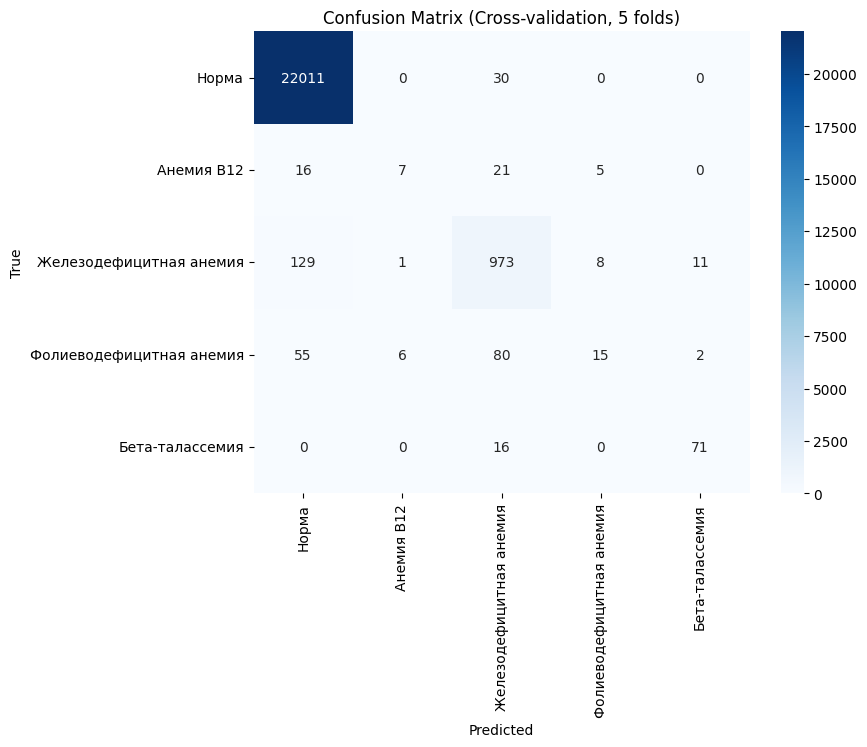


Обучение финальной модели на полной обучающей выборке...
=== Baseline: финальная оценка на тестовой выборке ===
                          precision    recall  f1-score   support

                   Норма       0.99      1.00      0.99      5511
              Анемия B12       0.50      0.17      0.25        12
 Железодефицитная анемия       0.90      0.88      0.89       280
Фолиеводефицитная анемия       0.62      0.12      0.21        40
         Бета-талассемия       0.90      0.86      0.88        22

                accuracy                           0.98      5865
               macro avg       0.78      0.61      0.64      5865
            weighted avg       0.98      0.98      0.98      5865

Baseline Macro F1: 0.6450


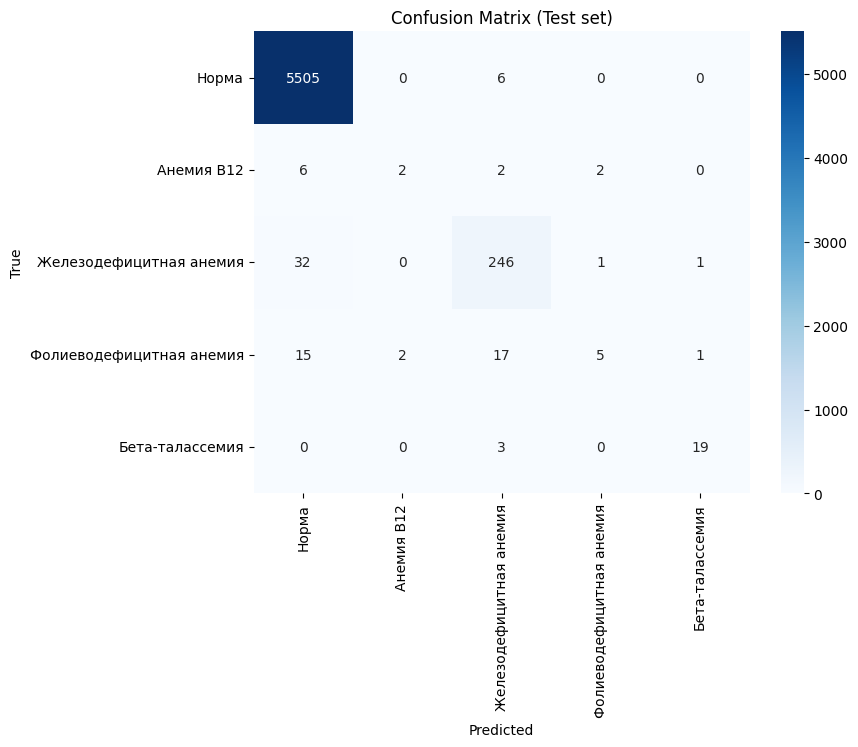

In [ ]:
# Базовая модель для baseline
baseline_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')

# Кросс-валидация на обучающей выборке
cv_folds = 5
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
cv_results = cross_validate(baseline_model, X_train_full_scaled, y_train_full,
                            cv=cv_folds, scoring=scoring, return_train_score=False)

print(f"=== Кросс-валидация ({cv_folds} фолдов) на обучающей выборке ===")
print(f"Accuracy:      {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std():.4f})")
print(f"Precision (macro): {cv_results['test_precision_macro'].mean():.4f} (+/- {cv_results['test_precision_macro'].std():.4f})")
print(f"Recall (macro):    {cv_results['test_recall_macro'].mean():.4f} (+/- {cv_results['test_recall_macro'].std():.4f})")
print(f"F1 (macro):        {cv_results['test_f1_macro'].mean():.4f} (+/- {cv_results['test_f1_macro'].std():.4f})")

# Классификационный отчёт и матрица ошибок по кросс-валидации
y_cv_pred = cross_val_predict(baseline_model, X_train_full_scaled, y_train_full, cv=cv_folds)
print("\nClassification Report (Cross-validation):")
print(classification_report(y_train_full, y_cv_pred, target_names=class_names))

cm_cv = confusion_matrix(y_train_full, y_cv_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cv, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix (Cross-validation, {cv_folds} folds)')
plt.show()

# Финальное обучение на всей train и оценка на тесте
print("\nОбучение финальной модели на полной обучающей выборке...")
baseline_model.fit(X_train_full_scaled, y_train_full)
y_pred_baseline = baseline_model.predict(X_test_scaled)

print("=== Baseline: финальная оценка на тестовой выборке ===")
print(classification_report(y_test, y_pred_baseline, target_names=class_names))
baseline_macro_f1 = f1_score(y_test, y_pred_baseline, average='macro')
print(f"Baseline Macro F1: {baseline_macro_f1:.4f}")

cm_test = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Test set)')
plt.show()

# Работа со стратегиями активного обучения на полном наборе данных

## Стратегии отбора образцов

In [ ]:
def uncertainty_least_confidence(proba):
    """1 - max(P) – чем больше, тем выше неуверенность."""

    return 1 - np.max(proba, axis=1)

def uncertainty_margin(proba):
    """Разница между вероятностями двух самых вероятных классов."""

    sorted_proba = np.sort(proba, axis=1)[:, ::-1]
    return sorted_proba[:, 0] - sorted_proba[:, 1]

def uncertainty_entropy(proba):
    """Энтропия распределения вероятностей."""

    return entropy(proba.T)  # entropy по строкам

def qbc_disagreement(proba_list):
    """
    Query-By-Committee: disagreement измеряется через энтропию голосования комитета.
    proba_list: список массивов вероятностей от каждой модели комитета.
    """

    # Усреднённое распределение вероятностей по комитету
    avg_proba = np.mean(proba_list, axis=0)
    return entropy(avg_proba.T)

## Цикл активного обучения

In [ ]:
def active_learning_loop_with_report(
    strategy, X_init, y_init, X_pool, y_pool_true,
    X_test, y_test, model_class, n_queries=10, query_size=20,
    class_names=None, random_state=42, **model_kwargs
):
    """
    Цикл активного обучения с оценкой качества по macro F1-score и отслеживанием per-class F1.
    Также выводит распределение классов, выбранных для разметки на каждом шаге.

    Возвращает:
        final_model    - обученная модель на последнем шаге
        X_labeled      - финальный набор размеченных признаков
        y_labeled      - финальные метки
        test_scores    - список macro F1 после каждого запроса
        per_class_f1_history - словарь с историей F1 для каждого класса
    """

    X_labeled = X_init.copy()
    y_labeled = y_init.copy()
    X_unlabeled = X_pool.copy()
    y_unlabeled_true = y_pool_true.copy()

    test_scores = []                # macro F1
    per_class_f1_history = {i: [] for i in np.unique(y_test)}  # для каждого класса

    per_class_precision_history = {i: [] for i in np.unique(y_test)}
    per_class_recall_history = {i: [] for i in np.unique(y_test)}

    # Инициализация моделей для QBC
    if strategy == 'qbc':
        models = [
            RandomForestClassifier(n_estimators=100, random_state=random_state, n_jobs=-1),
            LogisticRegression(max_iter=2000, solver='saga', random_state=random_state),
            SVC(probability=True, random_state=random_state),
        ]
    else:
        model = model_class(random_state=random_state, **model_kwargs)

    for query in range(n_queries):
        if strategy == 'qbc':
            proba_list = []
            for m in models:
                m.fit(X_labeled, y_labeled)
                proba = m.predict_proba(X_unlabeled)
                proba_list.append(proba)
            scores = qbc_disagreement(proba_list)
            query_indices = np.argsort(scores)[-query_size:]
        else:
            model.fit(X_labeled, y_labeled)
            proba = model.predict_proba(X_unlabeled)
            if strategy == 'least_conf':
                scores = uncertainty_least_confidence(proba)
            elif strategy == 'margin':
                scores = uncertainty_margin(proba)
            elif strategy == 'entropy':
                scores = uncertainty_entropy(proba)
            else:
                raise ValueError("Unknown strategy")
            query_indices = np.argsort(scores)[-query_size:]

        # Добавляем размеченные образцы
        X_new = X_unlabeled[query_indices]
        y_new = y_unlabeled_true[query_indices]
        X_labeled = np.vstack([X_labeled, X_new])
        y_labeled = np.concatenate([y_labeled, y_new])

        # Информация о выбранных классах
        selected_counts = Counter(y_new)
        print(f"\nQuery {query+1} - выбраны классы для разметки:")
        for cls, count in sorted(selected_counts.items()):
            cls_name = class_names[cls] if class_names is not None else str(cls)
            print(f"  Класс {cls} ({cls_name}): {count} объектов")

        # Удаляем из пула
        mask = np.ones(X_unlabeled.shape[0], dtype=bool)
        mask[query_indices] = False
        X_unlabeled = X_unlabeled[mask]
        y_unlabeled_true = y_unlabeled_true[mask]

        # Оценка на тесте (macro F1 и per-class F1)
        if strategy == 'qbc':
            eval_model = models[0]
            eval_model.fit(X_labeled, y_labeled)
        else:
            eval_model = model_class(random_state=random_state, **model_kwargs)
            eval_model.fit(X_labeled, y_labeled)

        y_pred = eval_model.predict(X_test)
        f1_macro = f1_score(y_test, y_pred, average='macro')
        test_scores.append(f1_macro)

        prec_per_class = precision_score(y_test, y_pred, average=None)
        rec_per_class = recall_score(y_test, y_pred, average=None)

        for cls, prec_val, rec_val in zip(np.unique(y_test), prec_per_class, rec_per_class):
            per_class_precision_history[cls].append(prec_val)
            per_class_recall_history[cls].append(rec_val)

        # Per-class F1
        f1_per_class = f1_score(y_test, y_pred, average=None)
        for cls, f1_val in zip(np.unique(y_test), f1_per_class):
            per_class_f1_history[cls].append(f1_val)

        print(f"Test F1-macro: {f1_macro:.4f}")
        print("Per-class F1:", {class_names[cls] if class_names else cls: round(f1,4)
                                 for cls, f1 in zip(np.unique(y_test), f1_per_class)})

    # Финальная модель
    if strategy == 'qbc':
        final_model = models[0]
        final_model.fit(X_labeled, y_labeled)
    else:
        final_model = model_class(random_state=random_state, **model_kwargs)
        final_model.fit(X_labeled, y_labeled)

    # Финальный отчёт
    y_pred_final = final_model.predict(X_test)
    print("\n=== Финальный отчёт ===")
    print(classification_report(y_test, y_pred_final, target_names=class_names))

    # Матрица ошибок
    cm = confusion_matrix(y_test, y_pred_final)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix (Final Model)')
    plt.show()

    return (final_model, X_labeled, y_labeled, test_scores,
        per_class_f1_history, per_class_precision_history, per_class_recall_history)

## Активное обучение на той же train-части

In [ ]:
# Начальная выборка из X_train_full_scaled
initial_size = 200
X_initial, X_pool, y_initial, y_pool = train_test_split(
    X_train_full_scaled, y_train_full, train_size=initial_size,
    random_state=42, stratify=y_train_full
)

y_initial = y_initial.values
y_pool = y_pool.values

print("Распределение классов в начальной выборке:")
unique, counts = np.unique(y_initial, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Класс {cls}: {cnt}")

print("Распределение классов в пуле:")
unique_pool, counts_pool = np.unique(y_pool, return_counts=True)
for cls, cnt in zip(unique_pool, counts_pool):
    print(f"  Класс {cls}: {cnt}")

Распределение классов в начальной выборке:
  Класс 0: 188
  Класс 2: 10
  Класс 3: 1
  Класс 4: 1
Распределение классов в пуле:
  Класс 0: 21853
  Класс 1: 49
  Класс 2: 1112
  Класс 3: 157
  Класс 4: 86


In [ ]:
len(y_pool)

23257


=== Стратегия: least_conf ===

Query 1 - выбраны классы для разметки:
  Класс 0 (Норма): 2 объектов
  Класс 1 (Анемия B12): 2 объектов
  Класс 2 (Железодефицитная анемия): 9 объектов
  Класс 3 (Фолиеводефицитная анемия): 5 объектов
  Класс 4 (Бета-талассемия): 2 объектов
Test F1-macro: 0.4528
Per-class F1: {'Норма': np.float64(0.9927), 'Анемия B12': np.float64(0.1176), 'Железодефицитная анемия': np.float64(0.8351), 'Фолиеводефицитная анемия': np.float64(0.0784), 'Бета-талассемия': np.float64(0.24)}

Query 2 - выбраны классы для разметки:
  Класс 0 (Норма): 2 объектов
  Класс 1 (Анемия B12): 2 объектов
  Класс 2 (Железодефицитная анемия): 5 объектов
  Класс 3 (Фолиеводефицитная анемия): 2 объектов
  Класс 4 (Бета-талассемия): 9 объектов
Test F1-macro: 0.5677
Per-class F1: {'Норма': np.float64(0.9923), 'Анемия B12': np.float64(0.125), 'Железодефицитная анемия': np.float64(0.8369), 'Фолиеводефицитная анемия': np.float64(0.0444), 'Бета-талассемия': np.float64(0.84)}

Query 3 - выбраны кла

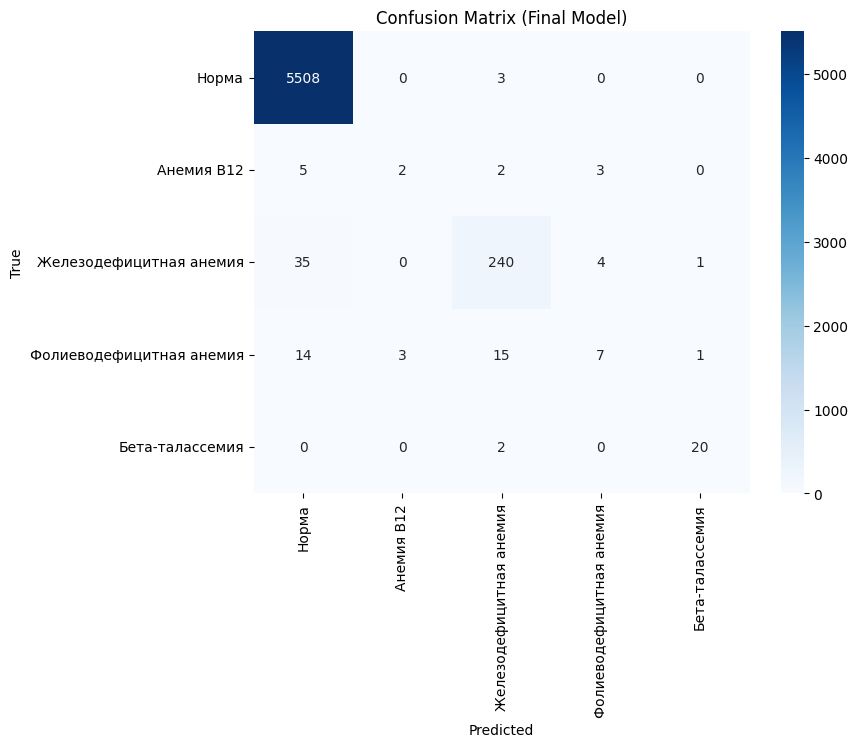


=== Стратегия: margin ===

Query 1 - выбраны классы для разметки:
  Класс 0 (Норма): 20 объектов


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Test F1-macro: 0.3626
Per-class F1: {'Норма': np.float64(0.9912), 'Анемия B12': np.float64(0.0), 'Железодефицитная анемия': np.float64(0.8217), 'Фолиеводефицитная анемия': np.float64(0.0), 'Бета-талассемия': np.float64(0.0)}

Query 2 - выбраны классы для разметки:
  Класс 0 (Норма): 20 объектов


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Test F1-macro: 0.3635
Per-class F1: {'Норма': np.float64(0.9913), 'Анемия B12': np.float64(0.0), 'Железодефицитная анемия': np.float64(0.8264), 'Фолиеводефицитная анемия': np.float64(0.0), 'Бета-талассемия': np.float64(0.0)}

Query 3 - выбраны классы для разметки:
  Класс 0 (Норма): 20 объектов


...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Test F1-macro: 0.3622
Per-class F1: {'Норма': np.float64(0.9917), 'Анемия B12': np.float64(0.0), 'Железодефицитная анемия': np.float64(0.8194), 'Фолиеводефицитная анемия': np.float64(0.0), 'Бета-талассемия': np.float64(0.0)}

Query 25 - выбраны классы для разметки:
  Класс 0 (Норма): 20 объектов


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Test F1-macro: 0.3619
Per-class F1: {'Норма': np.float64(0.9916), 'Анемия B12': np.float64(0.0), 'Железодефицитная анемия': np.float64(0.818), 'Фолиеводефицитная анемия': np.float64(0.0), 'Бета-талассемия': np.float64(0.0)}

=== Финальный отчёт ===
                          precision    recall  f1-score   support

                   Норма       0.99      1.00      0.99      5511
              Анемия B12       0.00      0.00      0.00        12
 Железодефицитная анемия       0.79      0.84      0.82       280
Фолиеводефицитная анемия       0.00      0.00      0.00        40
         Бета-талассемия       0.00      0.00      0.00        22

                accuracy                           0.98      5865
               macro avg       0.36      0.37      0.36      5865
            weighted avg       0.96      0.98      0.97      5865



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


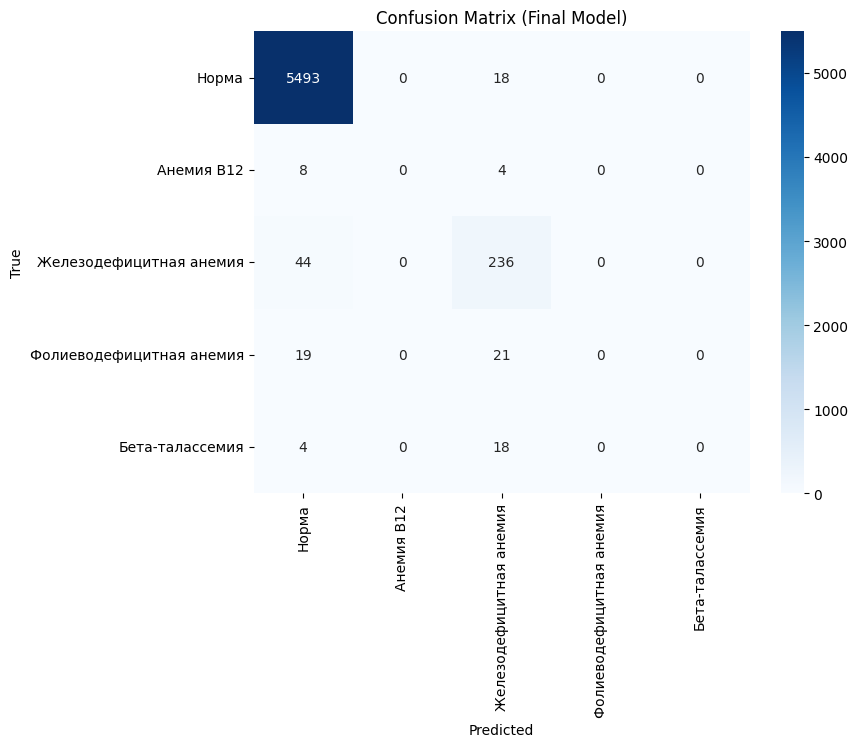


=== Стратегия: entropy ===

Query 1 - выбраны классы для разметки:
  Класс 1 (Анемия B12): 6 объектов
  Класс 2 (Железодефицитная анемия): 3 объектов
  Класс 3 (Фолиеводефицитная анемия): 5 объектов
  Класс 4 (Бета-талассемия): 6 объектов
Test F1-macro: 0.5139
Per-class F1: {'Норма': np.float64(0.9926), 'Анемия B12': np.float64(0.125), 'Железодефицитная анемия': np.float64(0.8419), 'Фолиеводефицитная анемия': np.float64(0.0476), 'Бета-талассемия': np.float64(0.5625)}

Query 2 - выбраны классы для разметки:
  Класс 0 (Норма): 1 объектов
  Класс 1 (Анемия B12): 3 объектов
  Класс 2 (Железодефицитная анемия): 5 объектов
  Класс 3 (Фолиеводефицитная анемия): 6 объектов
  Класс 4 (Бета-талассемия): 5 объектов
Test F1-macro: 0.6304
Per-class F1: {'Норма': np.float64(0.993), 'Анемия B12': np.float64(0.2353), 'Железодефицитная анемия': np.float64(0.852), 'Фолиеводефицитная анемия': np.float64(0.2857), 'Бета-талассемия': np.float64(0.7857)}

Query 3 - выбраны классы для разметки:
  Класс 0 (Но

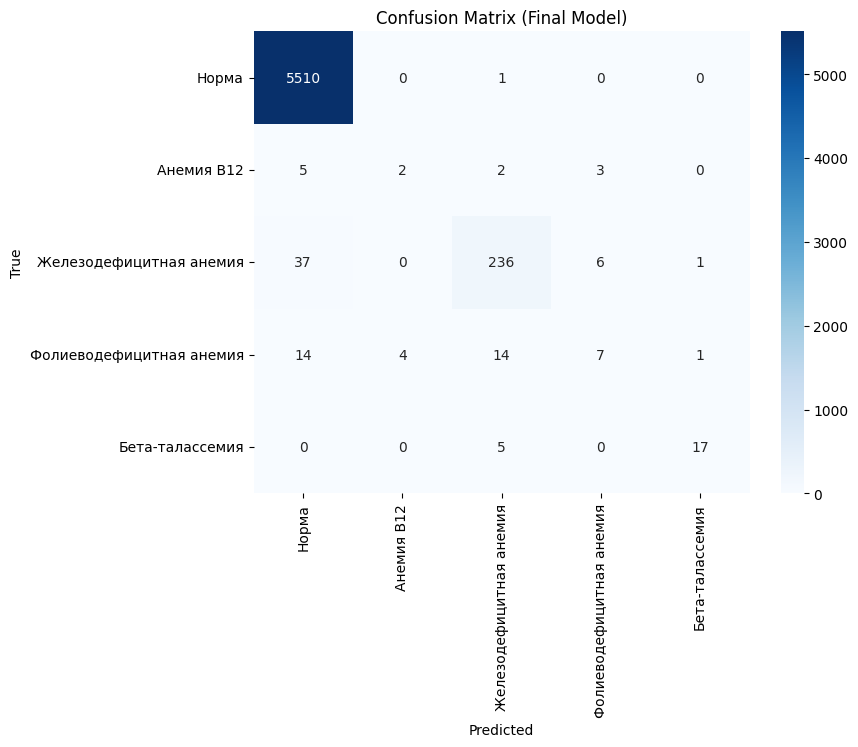


=== Стратегия: qbc ===

Query 1 - выбраны классы для разметки:
  Класс 0 (Норма): 3 объектов
  Класс 1 (Анемия B12): 7 объектов
  Класс 2 (Железодефицитная анемия): 5 объектов
  Класс 3 (Фолиеводефицитная анемия): 5 объектов


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Test F1-macro: 0.4060
Per-class F1: {'Норма': np.float64(0.9914), 'Анемия B12': np.float64(0.125), 'Железодефицитная анемия': np.float64(0.8225), 'Фолиеводефицитная анемия': np.float64(0.0909), 'Бета-талассемия': np.float64(0.0)}

Query 2 - выбраны классы для разметки:
  Класс 0 (Норма): 1 объектов
  Класс 1 (Анемия B12): 3 объектов
  Класс 2 (Железодефицитная анемия): 8 объектов
  Класс 3 (Фолиеводефицитная анемия): 4 объектов
  Класс 4 (Бета-талассемия): 4 объектов
Test F1-macro: 0.5313
Per-class F1: {'Норма': np.float64(0.9926), 'Анемия B12': np.float64(0.2222), 'Железодефицитная анемия': np.float64(0.8445), 'Фолиеводефицитная анемия': np.float64(0.1304), 'Бета-талассемия': np.float64(0.4667)}

Query 3 - выбраны классы для разметки:
  Класс 1 (Анемия B12): 2 объектов
  Класс 3 (Фолиеводефицитная анемия): 2 объектов
  Класс 4 (Бета-талассемия): 16 объектов
Test F1-macro: 0.5684
Per-class F1: {'Норма': np.float64(0.9923), 'Анемия B12': np.float64(0.1333), 'Железодефицитная анемия': np

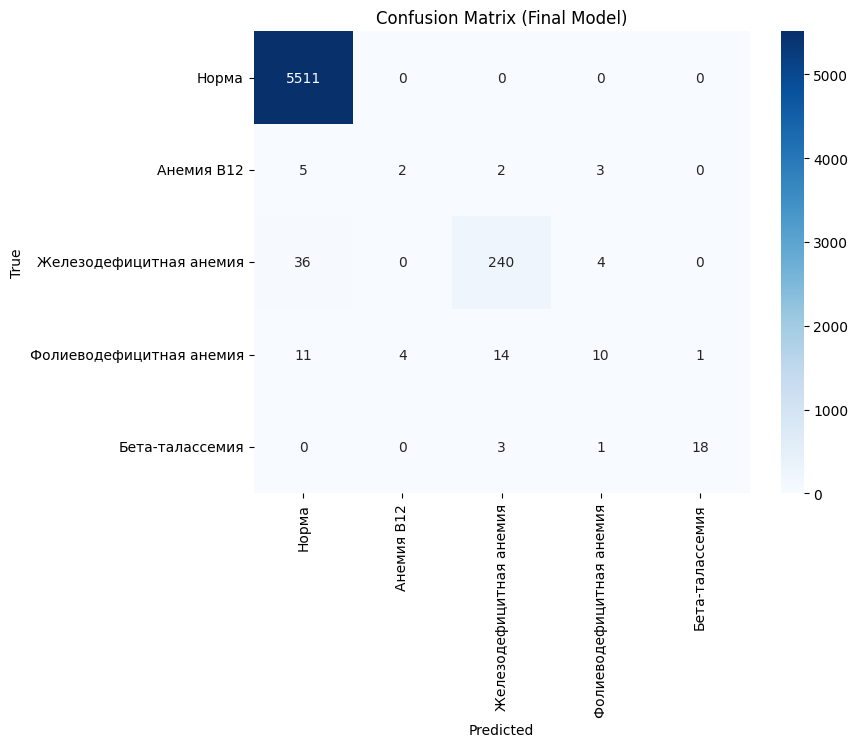

In [ ]:
# Параметры эксперимента
n_queries = 25
query_size = 20

# Теперь X_pool - это пул неразмеченных (уже отмасштабирован)
# Запускаем цикл активного обучения (используем вашу функцию с тем же тестом X_test_scaled)
strategies = ['least_conf', 'margin', 'entropy', 'qbc']
results = {}
for strat in strategies:
    print(f"\n=== Стратегия: {strat} ===")
    final_model, X_final, y_final, macro_f1_hist, per_class_f1_hist, per_class_prec_hist, per_class_rec_hist = active_learning_loop_with_report(
        strategy=strat,
        X_init=X_initial,
        y_init=y_initial,
        X_pool=X_pool,
        y_pool_true=y_pool,
        X_test=X_test_scaled,   # единый тест
        y_test=y_test,
        model_class=RandomForestClassifier,
        n_queries=n_queries,
        query_size=query_size,
        class_names=class_names,
        n_estimators=100,
        n_jobs=-1,
    )
    results[strat] = {
        'macro_f1': macro_f1_hist,
        'f1_per_class': per_class_f1_hist,
        'precision_per_class': per_class_prec_hist,
        'recall_per_class': per_class_rec_hist
    }

## Сравнительные графики

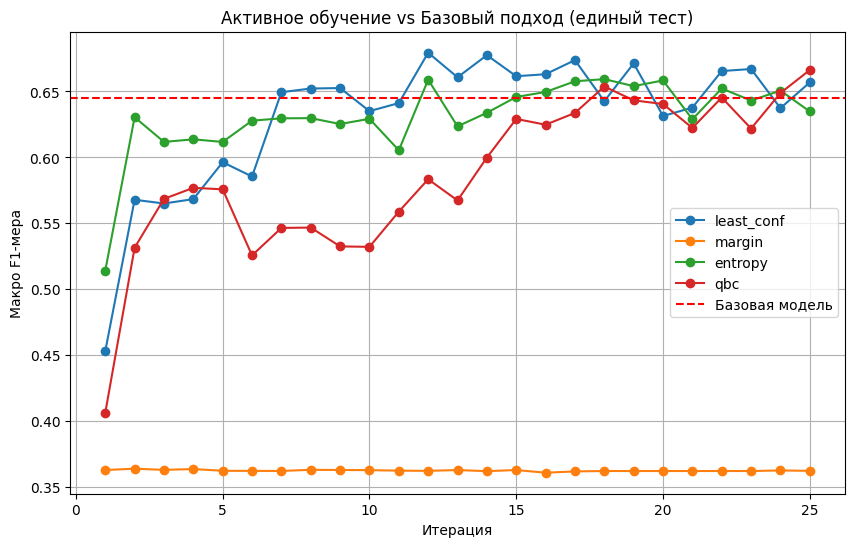

In [ ]:
plt.figure(figsize=(10, 6))
for name, data in results.items():
    plt.plot(range(1, len(data['macro_f1'])+1), data['macro_f1'], marker='o', label=name)
plt.axhline(y=baseline_macro_f1, color='red', linestyle='--', label='Базовая модель')
plt.xlabel('Итерация')
plt.ylabel('Макро F1-мера')
plt.title('Активное обучение vs Базовый подход (единый тест)')
plt.legend()
plt.grid(True)
plt.show()

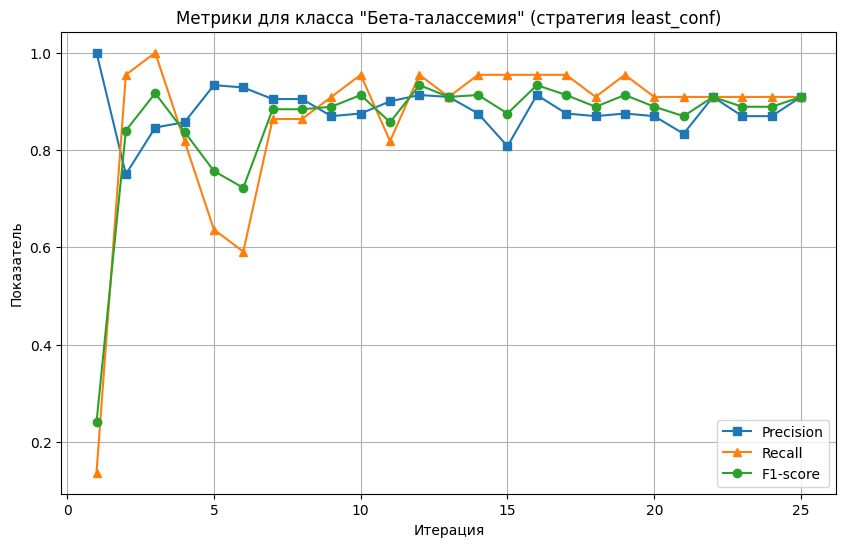

In [ ]:
thal_index = 4
chosen_strategy = 'least_conf'
queries = np.arange(1, n_queries + 1)

prec = results[chosen_strategy]['precision_per_class'][thal_index]
rec  = results[chosen_strategy]['recall_per_class'][thal_index]
f1   = results[chosen_strategy]['f1_per_class'][thal_index]

plt.figure(figsize=(10, 6))
plt.plot(queries, prec, marker='s', label='Precision')
plt.plot(queries, rec,  marker='^', label='Recall')
plt.plot(queries, f1,   marker='o', label='F1-score')
plt.xlabel('Итерация')
plt.ylabel('Показатель')
plt.title(f'Метрики для класса "Бета-талассемия" (стратегия {chosen_strategy})')
plt.legend()
plt.grid(True)
plt.show()

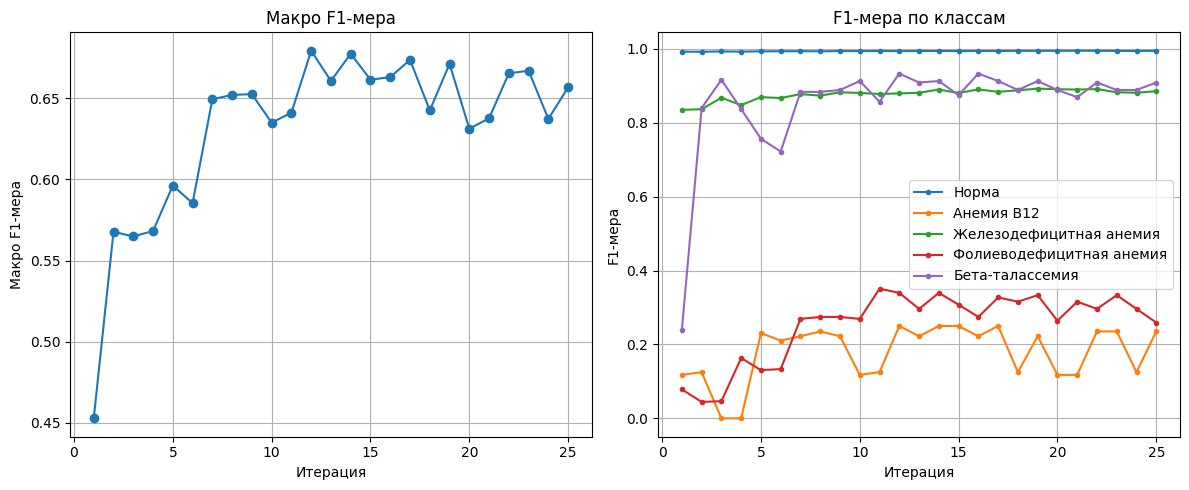

In [ ]:
# График macro F1
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(1, len(results['least_conf']['macro_f1'])+1), results['least_conf']['macro_f1'], marker='o')
plt.xlabel('Итерация')
plt.ylabel('Макро F1-мера')
plt.title('Макро F1-мера')
plt.grid(True)

# График per-class F1
plt.subplot(1,2,2)
for cls, history in results['least_conf']['f1_per_class'].items():
    plt.plot(range(1, len(history)+1), history, marker='.', label=class_names[cls])
plt.xlabel('Итерация')
plt.ylabel('F1-мера')
plt.title('F1-мера по классам')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

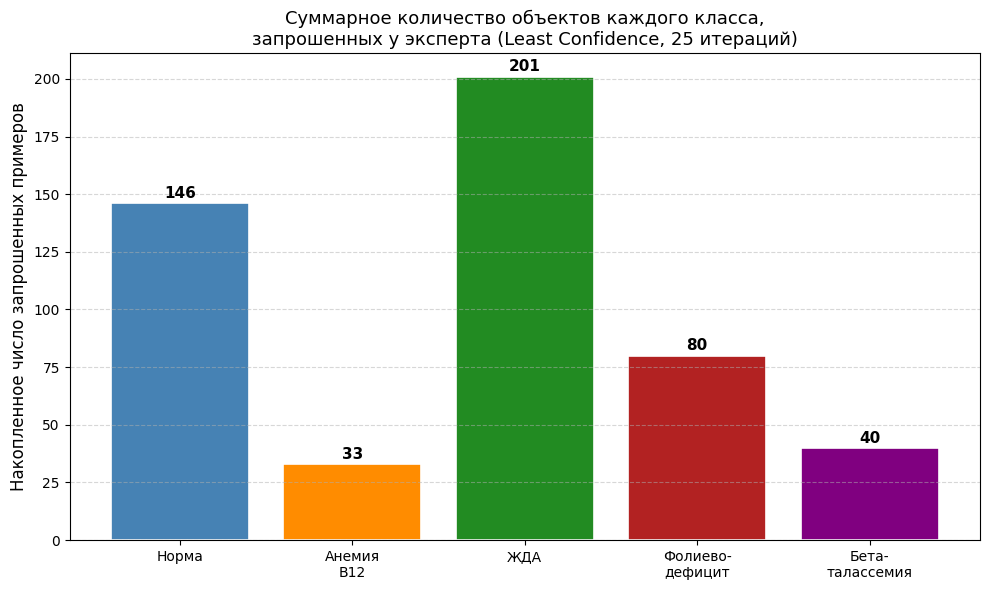

In [ ]:
# Данные: количество примеров каждого класса, запрошенных на каждой итерации
# Порядок: [Норма, B12, ЖДА, Фолиевая, Талассемия]
queries = [
    [2, 2, 9, 5, 2],
    [2, 2, 5, 2, 9],
    [13, 1, 4, 0, 2],
    [7, 1, 7, 3, 2],
    [0, 5, 12, 3, 0],
    [18, 1, 0, 1, 0],
    [2, 1, 6, 6, 5],
    [0, 2, 11, 7, 0],
    [7, 2, 3, 7, 1],
    [4, 0, 9, 6, 1],
    [1, 2, 14, 3, 0],
    [5, 2, 7, 2, 4],
    [8, 3, 5, 3, 1],
    [6, 0, 11, 1, 2],
    [4, 2, 7, 4, 3],
    [8, 2, 7, 3, 0],
    [14, 0, 4, 1, 1],
    [2, 0, 13, 3, 2],
    [4, 1, 11, 3, 1],
    [10, 0, 8, 2, 0],
    [14, 0, 4, 1, 1],
    [5, 1, 12, 1, 1],
    [5, 2, 7, 6, 0],
    [1, 0, 15, 3, 1],
    [4, 1, 10, 4, 1]
]

# Суммируем по итерациям
total_counts = np.array(queries).sum(axis=0)
classes = ['Норма', 'Анемия\nB12', 'ЖДА', 'Фолиево-\nдефицит', 'Бета-\nталассемия']
colors = ['steelblue', 'darkorange', 'forestgreen', 'firebrick', 'purple']

plt.figure(figsize=(10, 6))
bars = plt.bar(classes, total_counts, color=colors, edgecolor='white', linewidth=1.2)
plt.ylabel('Накопленное число запрошенных примеров', fontsize=12)
plt.title('Суммарное количество объектов каждого класса,\nзапрошенных у эксперта (Least Confidence, 25 итераций)', fontsize=13)

# Подписи значений над столбцами
for bar, count in zip(bars, total_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(count),
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Доля каждого класса в пуле
pool_dominance = [93.96, 0.21, 4.78, 0.68, 0.37]

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()